In [1]:

from tsl.datasets import Elergone
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure


c:\Users\matya\OneDrive\Bureau\Semester_project\SemesterProject\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Elergone(root='./data')


LD2011_2014.txt.zip: 261MB [05:07, 850kB/s]  


In [23]:
connectivity = dataset.get_connectivity(threshold=None,
                                        include_self=True,
                                        normalize_axis=1,
                                        layout="dense")


threshold = np.quantile(connectivity.flatten(), 0.8)

adj = connectivity > threshold

np.sum(adj) / adj.size

0.2

In [4]:
print(f"Sampling period: {dataset.freq}")
print(f"Has missing values: {dataset.has_mask}")
print(f"Percentage of missing values: {(1 - dataset.mask.mean()) * 100:.2f}%")
print(f"Has exogenous variables: {dataset.has_covariates}")
print(f"Covariates: {', '.join(dataset.covariates.keys())}")

Sampling period: <15 * Minutes>
Has missing values: True
Percentage of missing values: 20.15%
Has exogenous variables: False
Covariates: 


In [24]:
df = dataset.dataframe()

In [25]:
print(len(df))
df = df.resample('1h').sum()
print(len(df))

140256
35065


In [26]:
all_val = df.values
T, V = all_val.shape
all_val = all_val.reshape(T, V, 1)

all_val.shape


(35065, 370, 1)

In [27]:

idx_intersection = -1


def has_zero_subarray(arr, min_length, eps=1e-9):
    if len(arr) < min_length:
        return False
    
    # Count consecutive zeros
    max_zeros = 0
    current_zeros = 0
    
    for val in arr:
        if val < eps:
            current_zeros += 1
            max_zeros = max(max_zeros, current_zeros)
        else:
            current_zeros = 0
    
    return max_zeros >= min_length

# first cutoff after visual inspection
all_val_nz = all_val[10000:, :, :]

print(all_val_nz.shape)
node_idx_to_keep = []

for node_idx in range(all_val_nz.shape[1]):
    values = all_val_nz[:, node_idx, 0]
    if not has_zero_subarray(values, 72, np.mean(values) * 0.001): 
        node_idx_to_keep.append(node_idx)


all_val_nz = all_val_nz[:, node_idx_to_keep, :]

all_val_nz.shape

(25065, 370, 1)


(25065, 316, 1)

In [28]:
adj = adj[np.ix_(node_idx_to_keep, node_idx_to_keep)]

adj.shape

(316, 316)

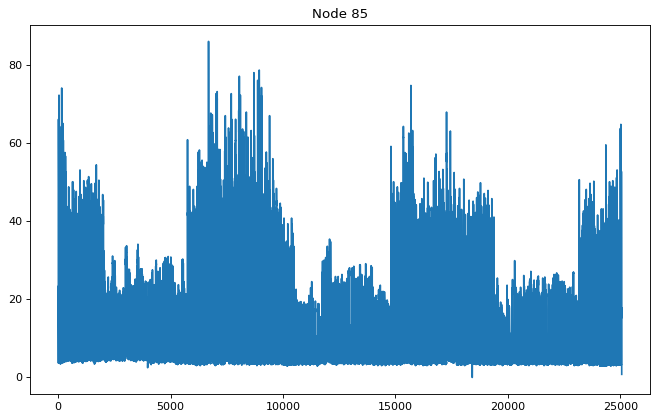

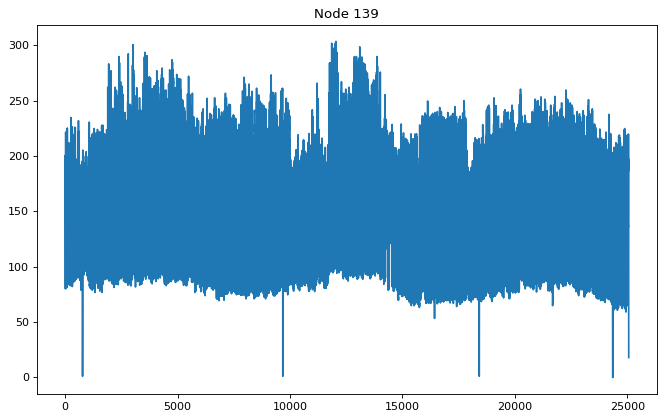

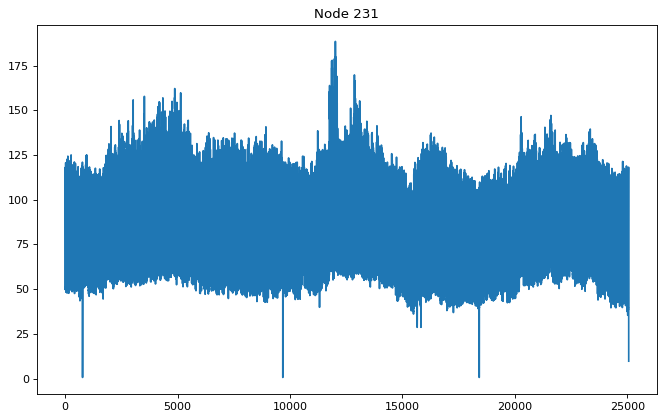

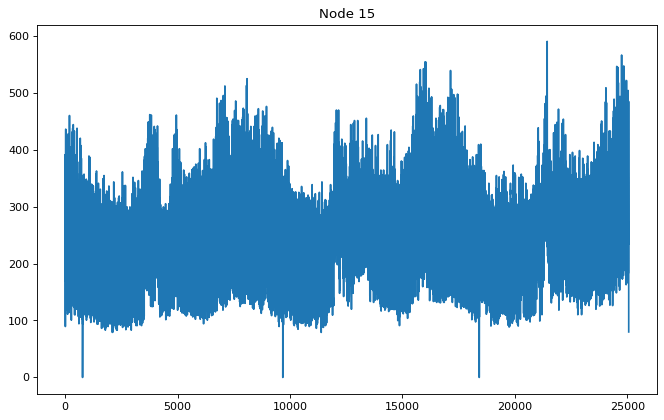

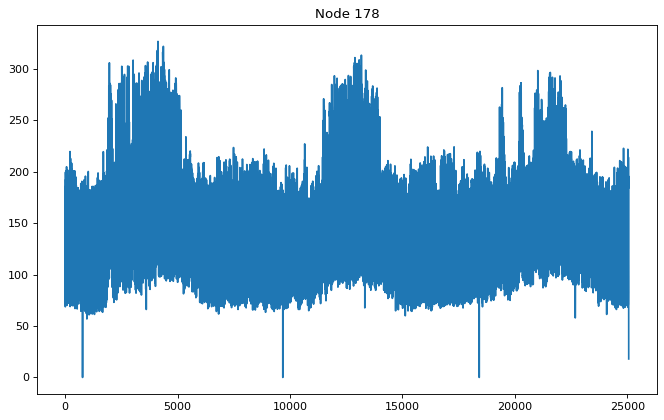

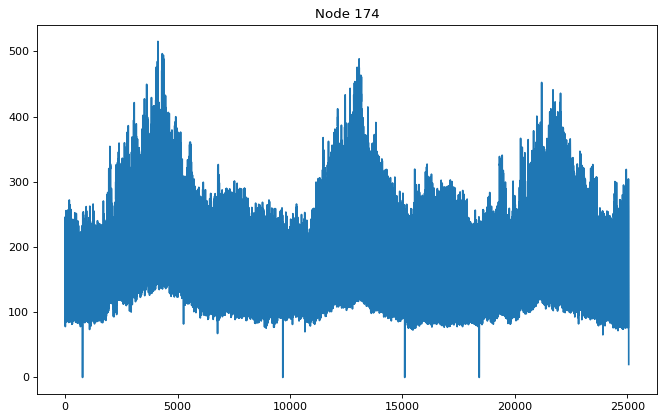

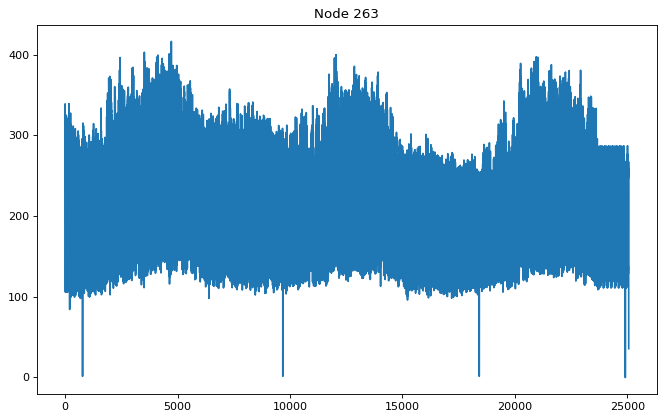

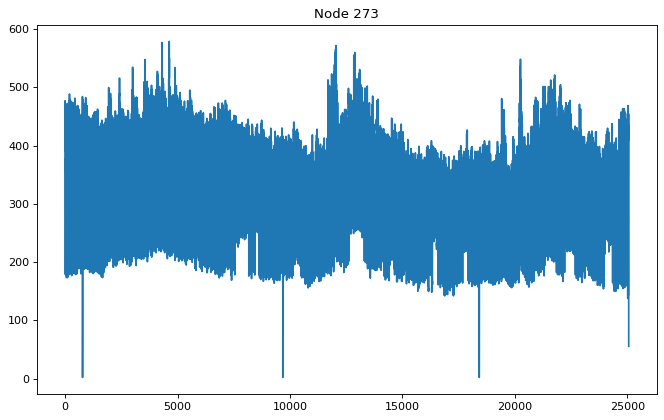

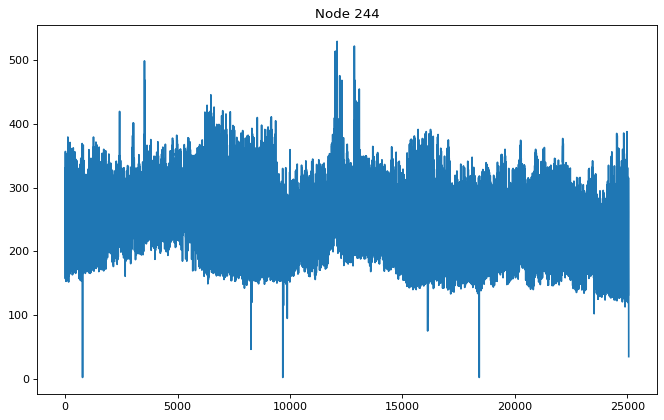

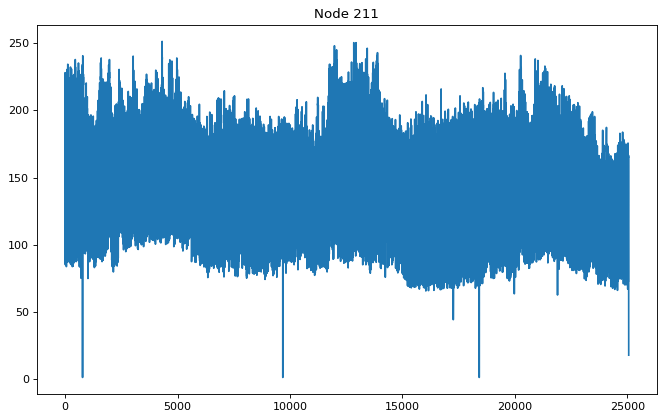

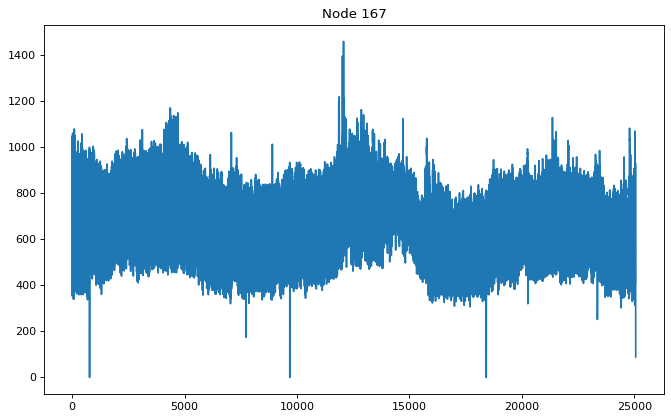

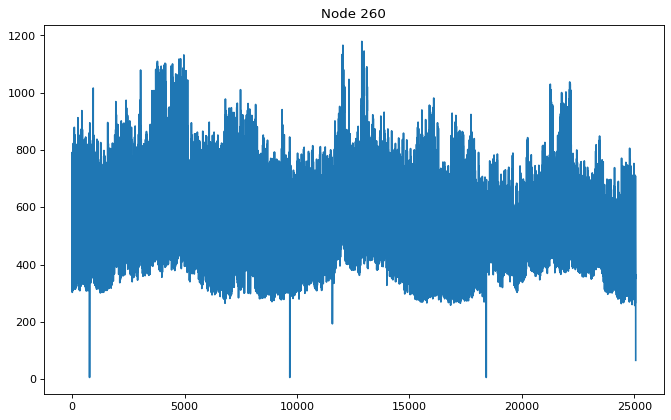

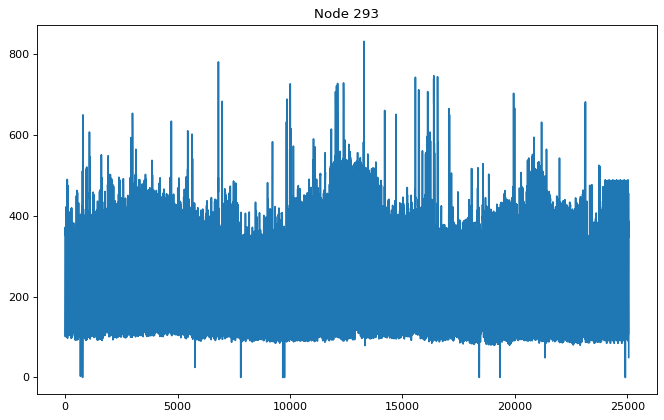

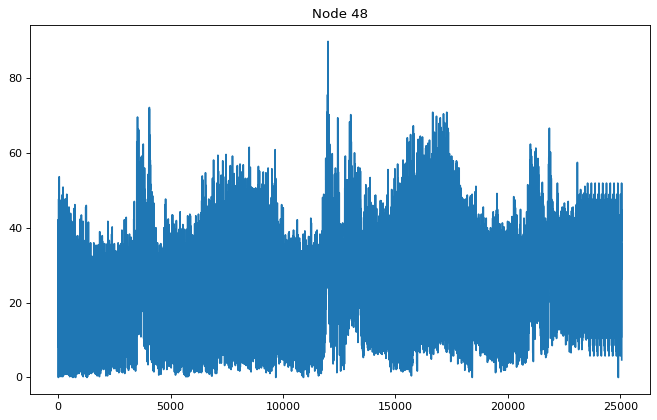

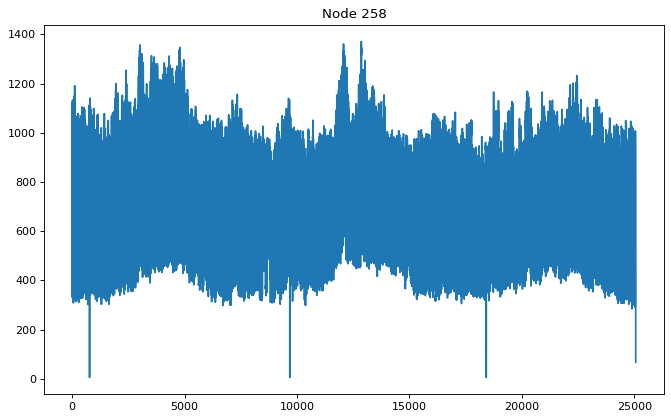

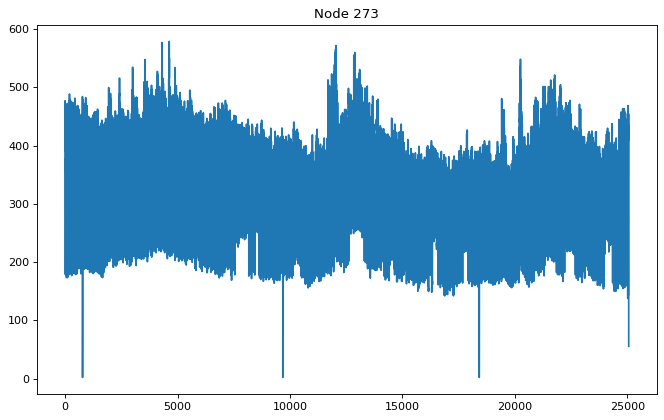

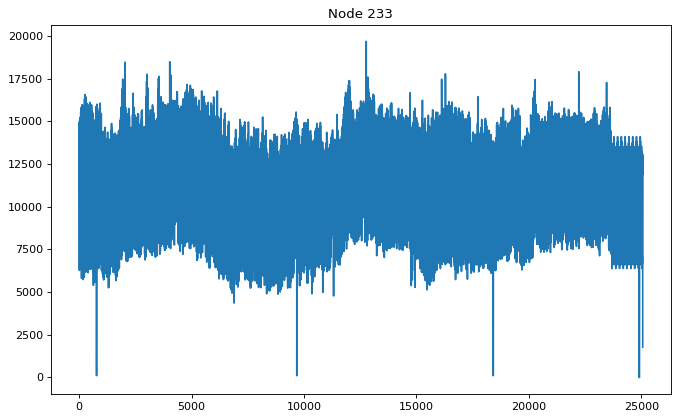

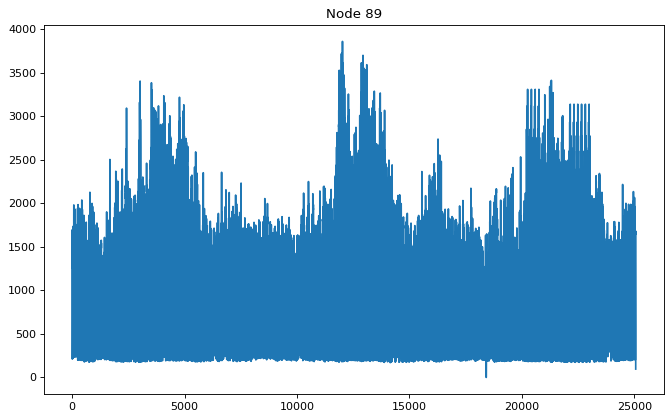

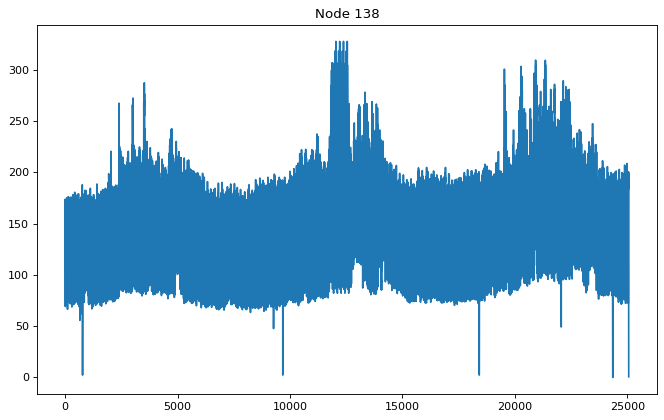

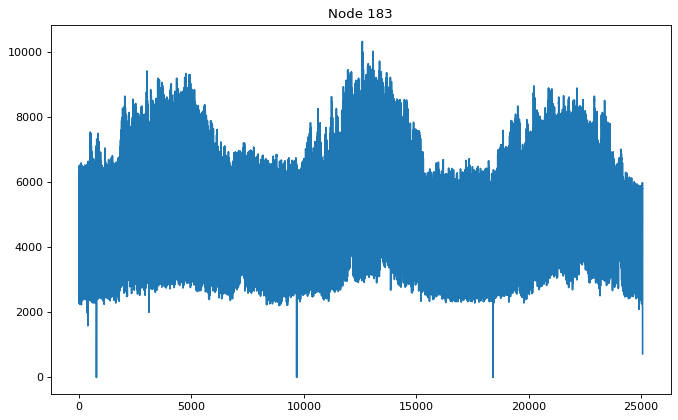

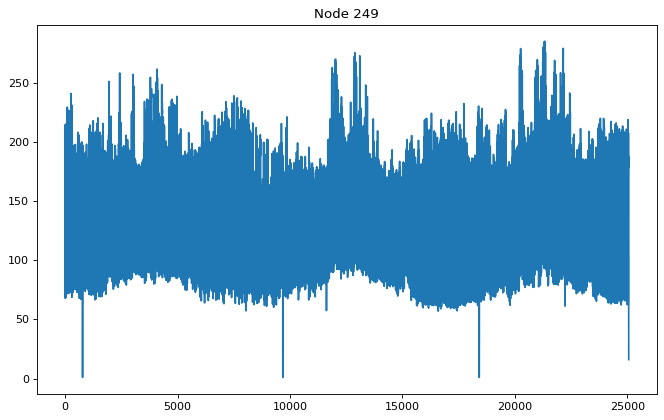

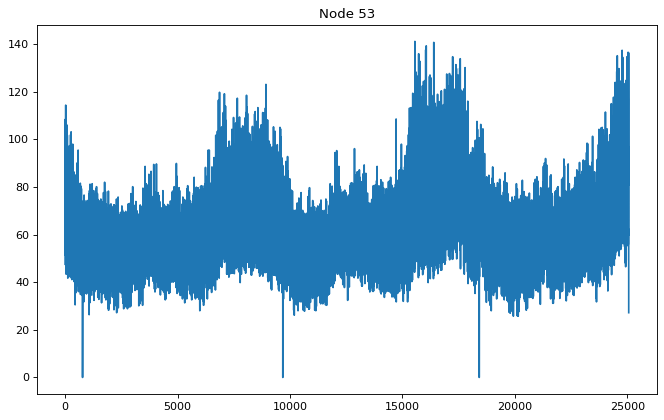

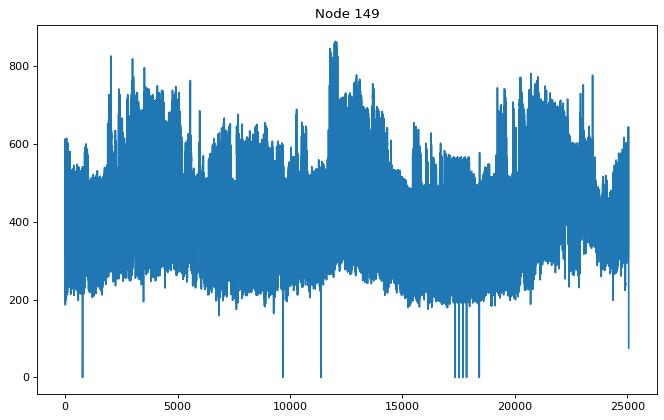

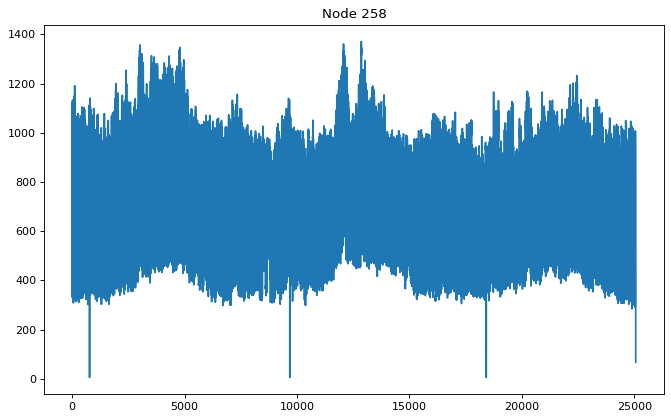

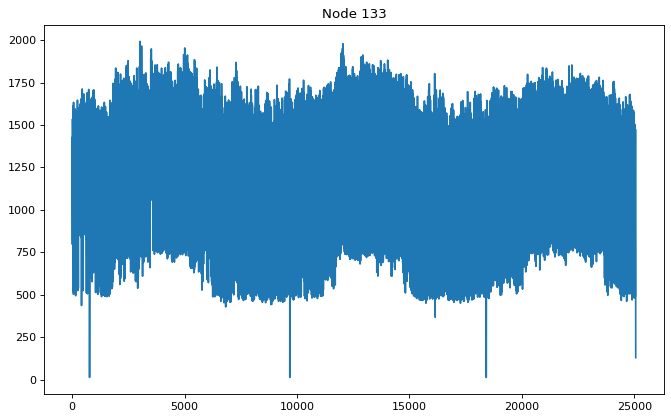

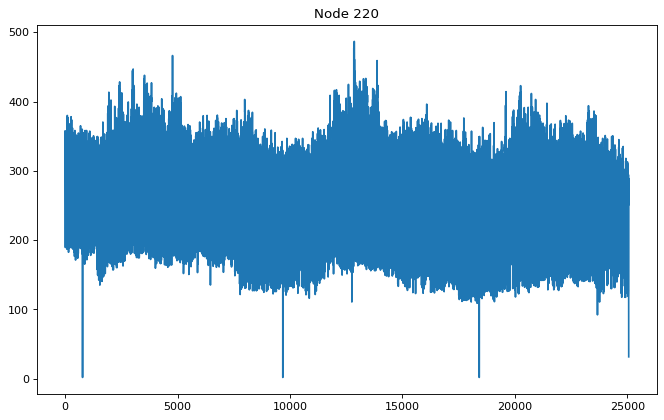

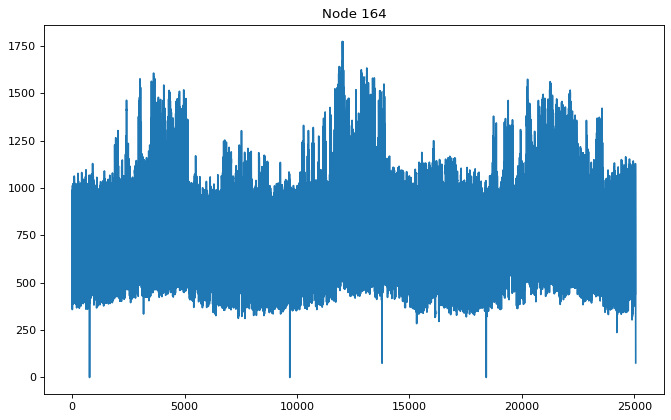

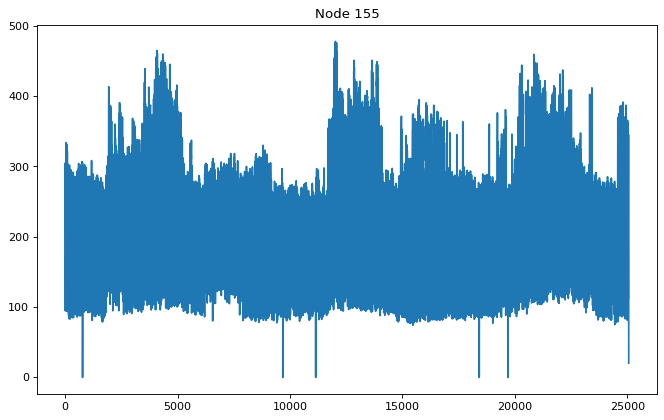

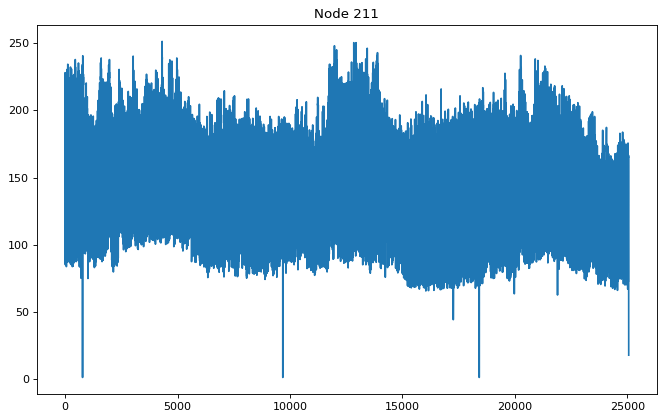

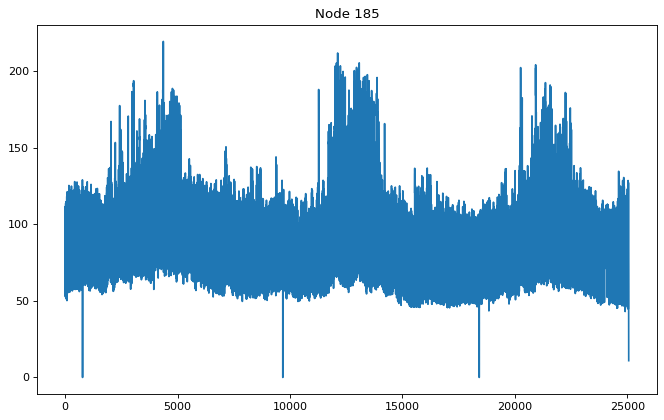

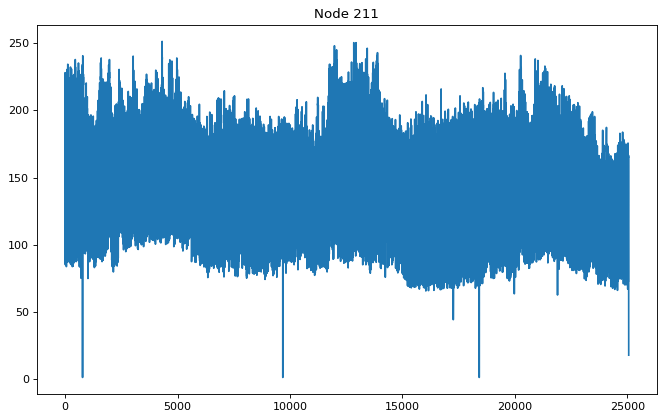

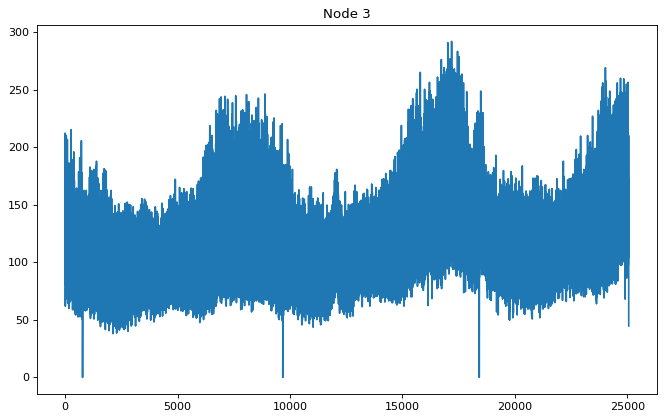

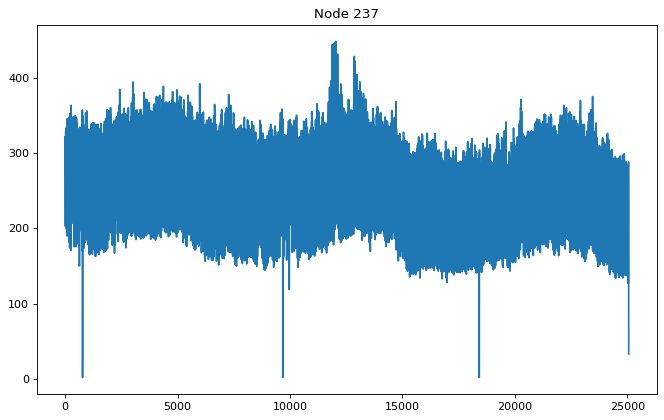

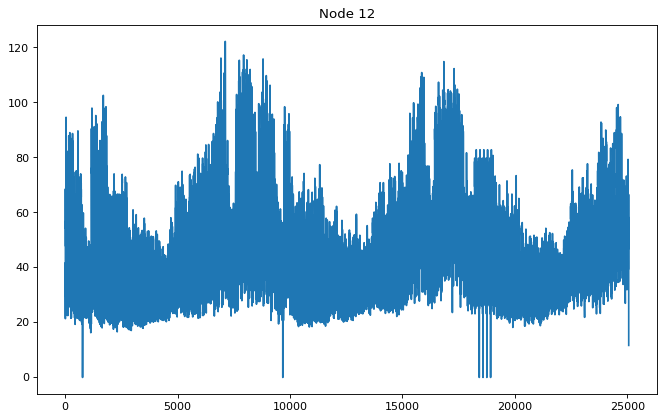

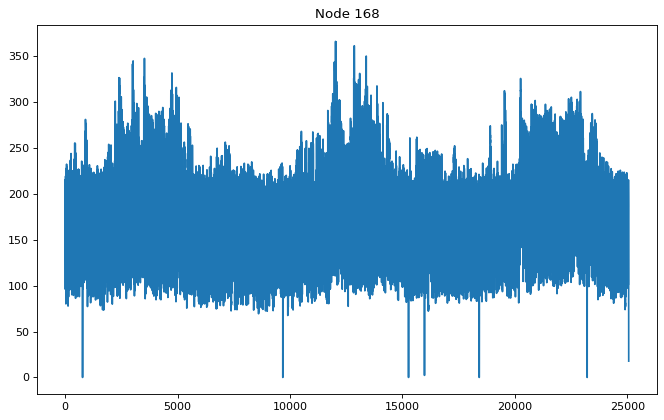

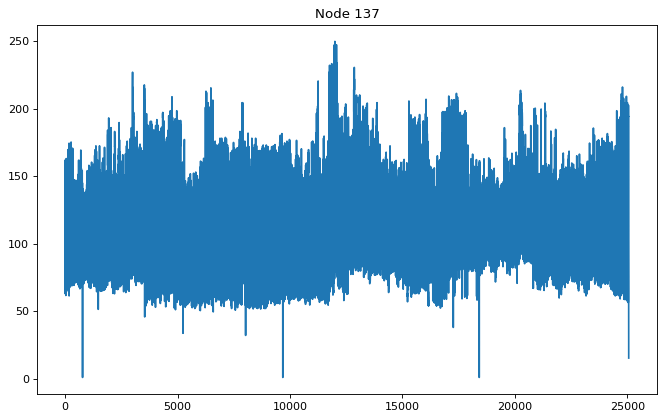

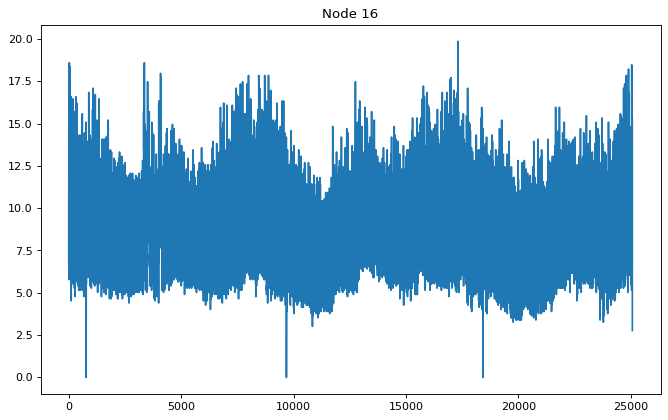

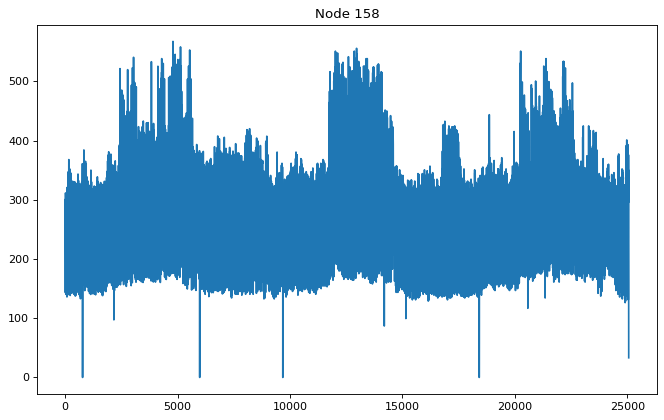

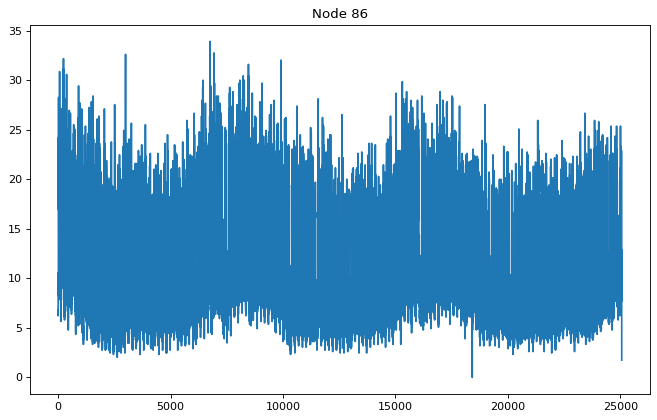

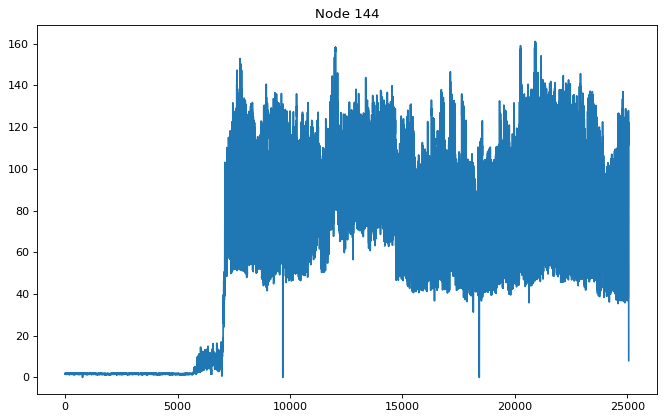

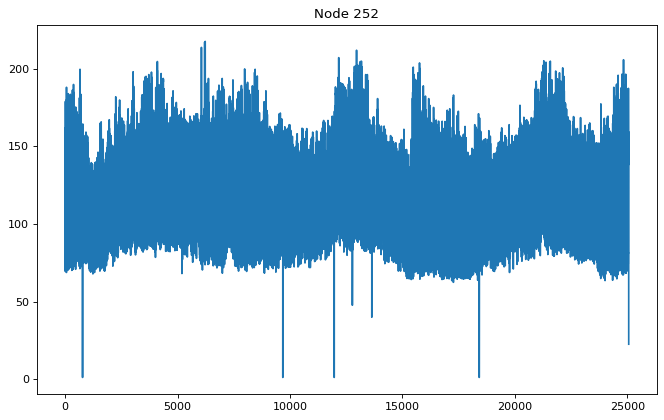

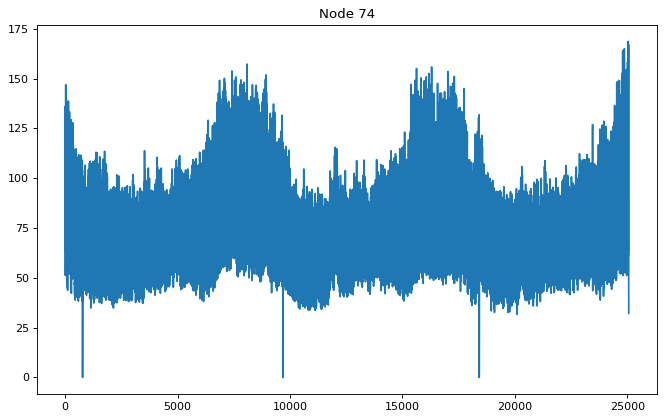

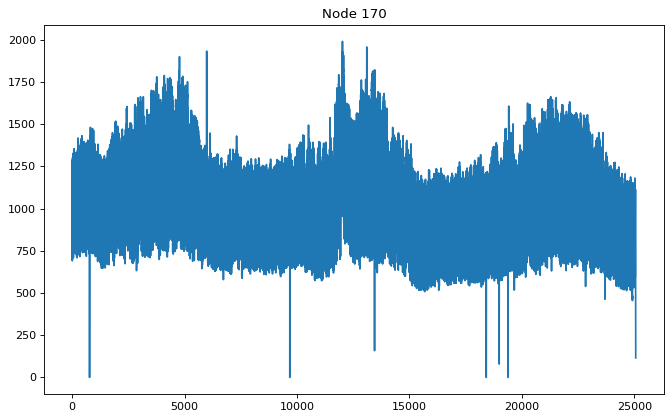

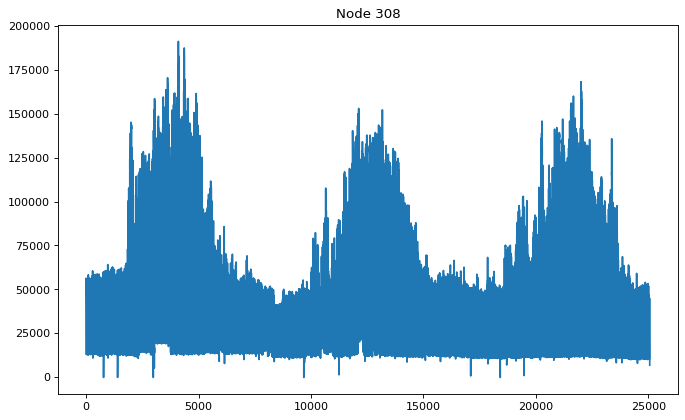

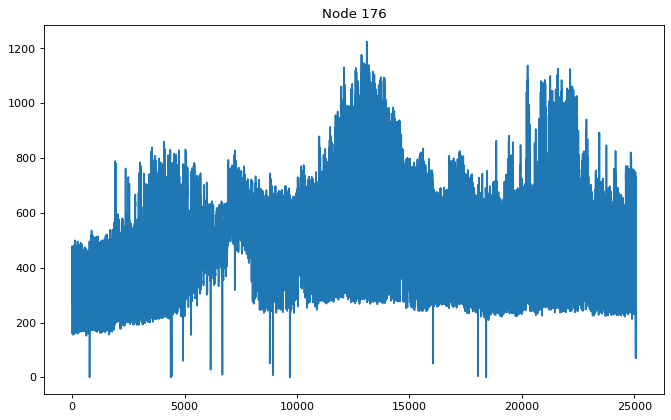

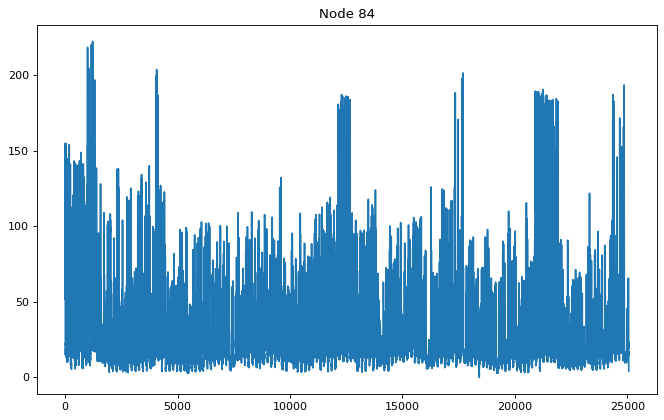

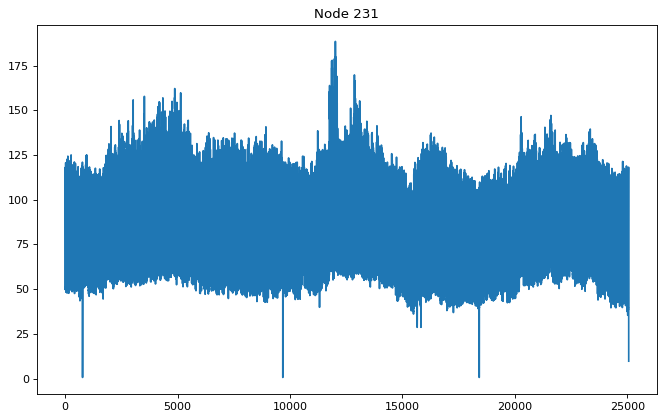

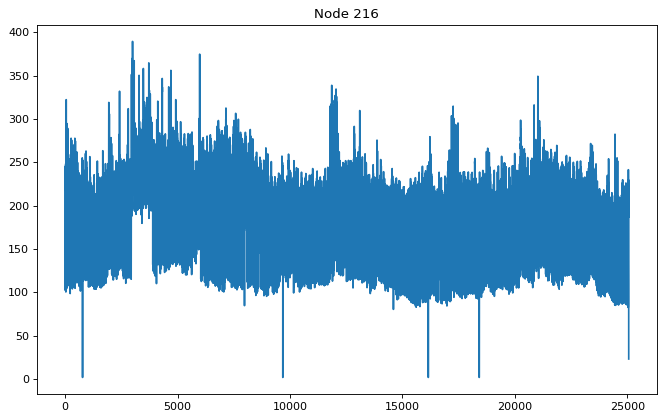

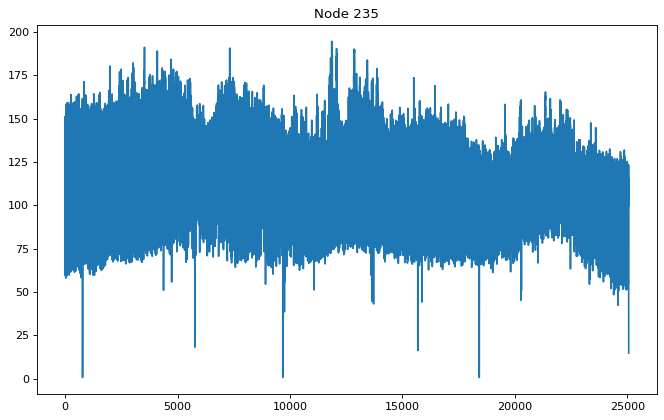

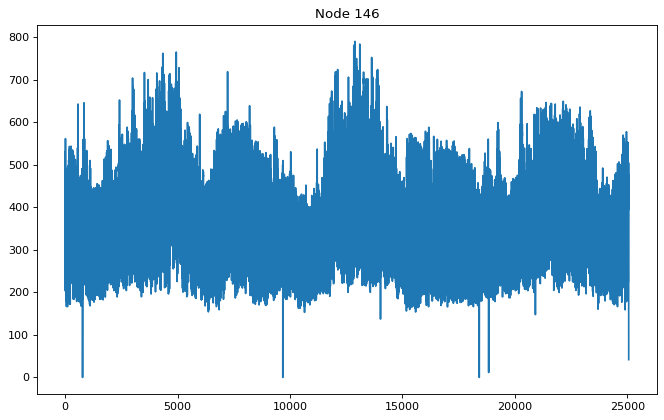

In [13]:

PLOT = True

rand_idx = np.random.randint(0, all_val_nz.shape[1], 50)


if PLOT:

    for node_idx in rand_idx: #all_val_nz.shape[1]
        figure(figsize=(10,  6), dpi=80)
        plt.plot(all_val_nz[:, node_idx, 0])
        plt.title(f"Node {node_idx}")
        plt.show()

In [ ]:
DATA_PATH = '../diffstg/data/dataset/electricity_benchmark/'

# np.save(os.path.join(DATA_PATH, 'flow.npy'), all_val_nz)
# np.save(os.path.join(DATA_PATH, 'adj.npy'), adj)

In [ ]:
# adj = np.load(os.path.join(DATA_PATH, 'adj.npy'))

# flow = np.load(os.path.join(DATA_PATH, 'flow.npy'))


0.9842773593975325


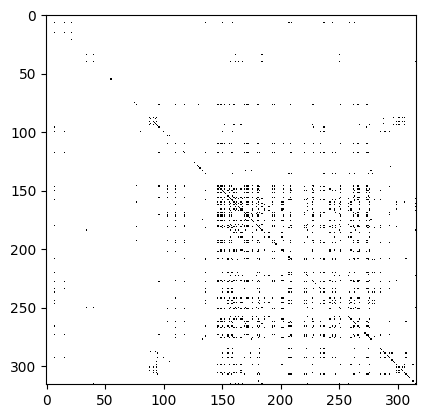

In [42]:

sparsity_rate = 1 - (adj.sum() / (adj.shape[0] * adj.shape[1]))
print(sparsity_rate)
plt.imshow(adj, cmap='Greys',  interpolation='nearest')

0.9873417721518988


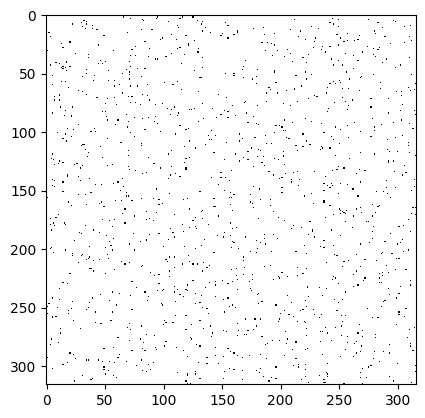

In [ ]:
learned_adj = np.load('../diffstg/preds/electricity_benchmark_learned_binarized.npy')

sparsity_rate = 1 - (learned_adj.sum() / (learned_adj.shape[0] * learned_adj.shape[1]))
print(sparsity_rate)
plt.imshow(learned_adj, cmap='Greys',  interpolation='nearest')

In [44]:
np.linalg.norm(adj - learned_adj, ord='fro')

52.915028